In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [29]:
import numpy as np
import tensorflow as tf
import random

# Fix seeds
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [30]:
df = pd.read_csv("application_train.csv", nrows=30000)

# Drop high missing
missing = df.isnull().mean()
df = df.drop(columns=missing[missing > 0.4].index)

# Fill missing
df = df.fillna(df.median(numeric_only=True))

# Encode categorical
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col].astype(str))

# Split
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [31]:
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)

    return [name, acc, prec, rec, f1, roc]

In [32]:
input_dim = X_train.shape[1]

# Autoencoder
inp = Input(shape=(input_dim,))
enc = Dense(64, activation='relu')(inp)
enc = Dense(32, activation='relu')(enc)
latent = Dense(16, activation='relu')(enc)

dec = Dense(32, activation='relu')(latent)
dec = Dense(64, activation='relu')(dec)
out = Dense(input_dim)(dec)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train, X_train, epochs=10, batch_size=256, verbose=0)

# Encoder
encoder = Model(inp, latent)
X_train_enc = encoder.predict(X_train)
X_test_enc = encoder.predict(X_test)

# Classifier
clf = tf.keras.Sequential([
    Dense(32, activation='relu', input_shape=(16,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

clf.compile(optimizer='adam', loss='binary_crossentropy')
clf.fit(X_train_enc, y_train, epochs=10, batch_size=128, verbose=0)

y_prob_ae = clf.predict(X_test_enc).ravel()

750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step


/Users/nitin/tf_m3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step


In [33]:
class VAE(tf.keras.Model):
    def __init__(self, input_dim, latent_dim=16):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.dense1 = tf.keras.layers.Dense(64, activation='relu')
        self.z_mean_layer = tf.keras.layers.Dense(latent_dim)
        self.z_log_var_layer = tf.keras.layers.Dense(latent_dim)

        # Decoder
        self.dense2 = tf.keras.layers.Dense(64, activation='relu')
        self.output_layer = tf.keras.layers.Dense(input_dim)

    def encode(self, x):
        h = self.dense1(x)
        z_mean = self.z_mean_layer(h)
        z_log_var = self.z_log_var_layer(h)

        # ✅ FIX: prevent NaN explosion
        z_log_var = tf.clip_by_value(z_log_var, -10, 10)

        return z_mean, z_log_var

    def reparameterize(self, z_mean, z_log_var):
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def decode(self, z):
        h = self.dense2(z)
        return self.output_layer(h)

    def call(self, x):
        z_mean, z_log_var = self.encode(x)
        z = self.reparameterize(z_mean, z_log_var)
        return self.decode(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var = self.encode(data)
            z = self.reparameterize(z_mean, z_log_var)
            reconstruction = self.decode(z)

            # Reconstruction loss
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {"loss": total_loss}


# Train VAE
vae = VAE(input_dim=X_train.shape[1])
vae.compile(optimizer='adam')

vae.fit(X_train, epochs=10, batch_size=256)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0000e+00 
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0000e+00
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0000e+00
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0000e+00
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0000e+00
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0000e+00
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0000e+00
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0000e+00
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0000e+00
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0000e+00


In [34]:
def get_encoded_features(model, X):
    z_mean, _ = model.encode(X)
    return z_mean.numpy()

X_train_vae = get_encoded_features(vae, X_train)
X_test_vae = get_encoded_features(vae, X_test)

In [35]:
clf_vae = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(16,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

clf_vae.compile(optimizer='adam', loss='binary_crossentropy')

clf_vae.fit(
    X_train_vae,
    y_train,
    epochs=10,
    batch_size=128,
    class_weight={0:1, 1:3}   # ✅ FIX imbalance
)

y_prob_vae = clf_vae.predict(X_test_vae).ravel()

Epoch 1/10


/Users/nitin/tf_m3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6316   
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5914 
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5841 
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5802 
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5784 
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5777 
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5775 
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5773 
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5773 
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5772 
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step


In [36]:
inp = tf.keras.Input(shape=(X_train.shape[1],))

x = tf.keras.layers.Dense(64, activation='relu')(inp)
x = tf.keras.layers.Dense(32, activation='relu')(x)
latent = tf.keras.layers.Dense(16, activation='relu')(x)

# classifier output
pred = tf.keras.layers.Dense(1, activation='sigmoid')(latent)

# reconstruction
dec = tf.keras.layers.Dense(32, activation='relu')(latent)
dec = tf.keras.layers.Dense(64, activation='relu')(dec)
recon = tf.keras.layers.Dense(X_train.shape[1])(dec)

hybrid = tf.keras.Model(inp, [recon, pred])

hybrid.compile(
    optimizer='adam',
    loss=['mse', 'binary_crossentropy'],
    loss_weights=[0.5, 1.0]
)

hybrid.fit(
    X_train,
    [X_train, y_train],
    epochs=10,
    batch_size=256,
    verbose=0
)

# 🔥 prediction
_, y_prob_hybrid = hybrid.predict(X_test)
y_prob_hybrid = y_prob_hybrid.ravel()

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

latent_dim = X_train_enc.shape[1]

clf_bal = Sequential([
    Dense(32, activation='relu', input_shape=(latent_dim,)),
    Dense(1, activation='sigmoid')
])

clf_bal.compile(optimizer='adam', loss='binary_crossentropy')

clf_bal.fit(
    X_train_enc,
    y_train,
    epochs=10,
    batch_size=128,
    class_weight={0:1, 1:3},
    verbose=0
)

y_prob_bal = clf_bal.predict(X_test_enc).ravel()

/Users/nitin/tf_m3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step


In [38]:
y_prob_ae = np.nan_to_num(y_prob_ae)
y_prob_vae = np.nan_to_num(y_prob_vae)
y_prob_hybrid = np.nan_to_num(y_prob_hybrid)
y_prob_bal = np.nan_to_num(y_prob_bal)

In [39]:
def evaluate_model(name, y_true, y_prob, threshold=0.3):

    y_prob = np.nan_to_num(y_prob)
    y_pred = (y_prob > threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = 0

    return [name, acc, prec, rec, f1, roc]

In [40]:
results = []

results.append(evaluate_model("AE + NN", y_test, y_prob_ae))
results.append(evaluate_model("VAE + NN", y_test, y_prob_vae))
results.append(evaluate_model("Hybrid AE", y_test, y_prob_hybrid))
results.append(evaluate_model("AE + Imbalance + Thresh", y_test, y_prob_bal))

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
)

print(results_df)

                     Model  Accuracy  Precision    Recall        F1   ROC_AUC
0                  AE + NN  0.561167   0.069795  0.356557  0.116739  0.469883
1                 VAE + NN  0.819500   0.136752  0.229508  0.171385  0.621849
2                Hybrid AE  0.893000   0.218978  0.122951  0.157480  0.652691
3  AE + Imbalance + Thresh  0.798167   0.144543  0.301230  0.195349  0.635943


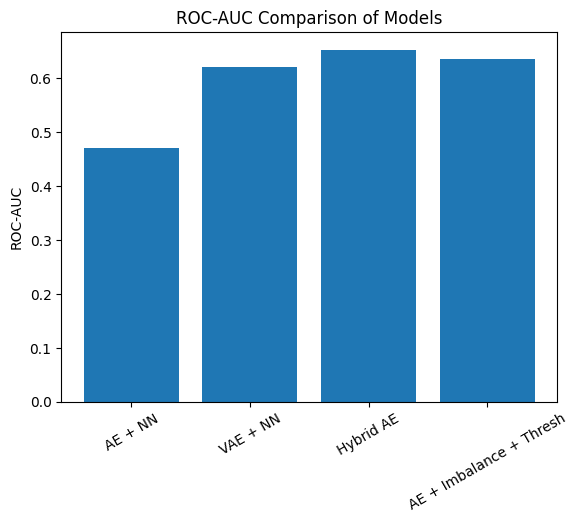

In [41]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["ROC_AUC"])
plt.xticks(rotation=30)
plt.title("ROC-AUC Comparison of Models")
plt.ylabel("ROC-AUC")
plt.show()